<a href="https://colab.research.google.com/github/Himanshu530-collab/BlogSphere/blob/main/testing_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving test_image.zip to test_image.zip


In [ ]:
import zipfile
import os

zip_path = "test_image.zip"   # Your zipped test_image folder
extract_dir = "test_image"    # Folder to extract into

# Make sure the extraction folder exists
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ Unzipped '{zip_path}' into '{extract_dir}'")


✅ Unzipped 'test_image.zip' into 'test_image'


In [ ]:
from google.colab import files

uploaded = files.upload()  # This will prompt you to select files from your computer

# After uploading, you can check if the file is uploaded:
import os
print(os.listdir())


Saving best_model_weights.pth to best_model_weights.pth
['.config', 'best_model_weights.pth', 'test_image.zip', 'test_image', 'sample_data']


In [ ]:
import torch
from torchvision import models
from torch import nn

# Step 1: Define the number of output classes
num_classes = 5  # Set this to match your classification task

# Step 2: Rebuild the same model architecture as during training
model = models.resnet18(pretrained=False)  # pretrained=False since you're loading custom weights
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Step 3: Load saved weights
model.load_state_dict(torch.load('best_model_weights.pth', map_location=torch.device('cpu')))

# Step 4: Set the model to evaluation mode
model.eval()

print("✅ Model loaded successfully and ready for inference.")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully and ready for inference.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [ ]:
import os
from PIL import Image
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

test_dir = 'test_image/test_image/Teeth Images'  # point to the actual images folder
valid_exts = ('.jpg', '.jpeg', '.png')

class_names = ['gingivitis', 'hypodontia', 'mouth_ulcer', 'tartar', 'tooth_discoloration']

for img_name in os.listdir(test_dir):
    if not img_name.lower().endswith(valid_exts):
        continue

    img_path = os.path.join(test_dir, img_name)

    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")
        continue

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, preds = torch.max(outputs, 1)

    print(f"Image: {img_name} --> Predicted class: {class_names[preds.item()]}")


Image: (7).JPG --> Predicted class: hypodontia
Image: (1).JPG --> Predicted class: hypodontia
Image: (9).JPG --> Predicted class: hypodontia
Image: 12.jpg --> Predicted class: hypodontia
Image: 38.jpg --> Predicted class: hypodontia
Image: 20.jpg --> Predicted class: hypodontia
Image: 16.jpg --> Predicted class: hypodontia
Image: (41).jpg --> Predicted class: tartar
Image: 18.jpg --> Predicted class: mouth_ulcer
Image: 17.jpg --> Predicted class: hypodontia
Image: (24).jpg --> Predicted class: hypodontia
Image: (6).JPG --> Predicted class: hypodontia
Image: 13.jpg --> Predicted class: hypodontia
Image: (44).jpg --> Predicted class: tartar
Image: 40.jpg --> Predicted class: tooth_discoloration
Image: (8).JPG --> Predicted class: hypodontia
Image: (26).jpg --> Predicted class: tartar
Image: (50).jpg --> Predicted class: tartar
Image: (47).jpg --> Predicted class: tartar
Image: (43).jpg --> Predicted class: gingivitis
Image: (2).JPG --> Predicted class: hypodontia
Image: (49).jpg --> Pred

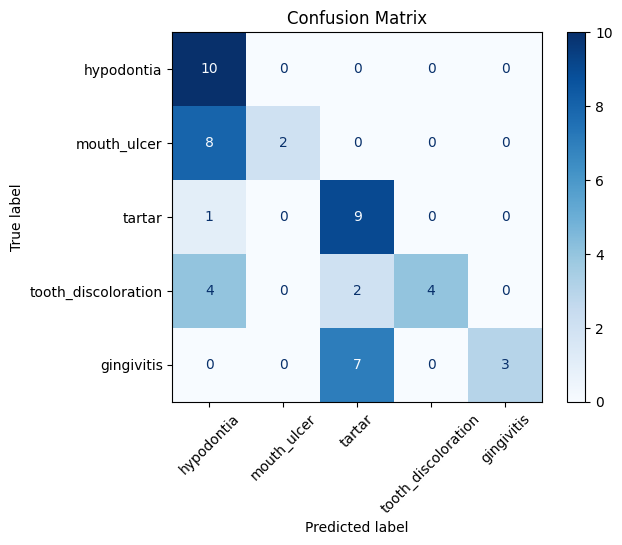

In [ ]:
import re
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_true_label(img_num):
    if 1 <= img_num <= 10:
        return 'hypodontia'
    elif 11 <= img_num <= 20:
        return 'mouth_ulcer'
    elif 21 <= img_num <= 30:
        return 'tartar'
    elif 31 <= img_num <= 40:
        return 'tooth_discoloration'
    elif 41 <= img_num <= 50:
        return 'gingivitis'
    else:
        return None

predicted_lines = [
      "Image: (7).JPG --> Predicted class: hypodontia",
    "Image: (1).JPG --> Predicted class: hypodontia",
    "Image: (9).JPG --> Predicted class: hypodontia",
    "Image: 12.jpg --> Predicted class: hypodontia",
    "Image: 38.jpg --> Predicted class: hypodontia",
    "Image: 20.jpg --> Predicted class: hypodontia",
    "Image: 16.jpg --> Predicted class: hypodontia",
    "Image: (41).jpg --> Predicted class: tartar",
    "Image: 18.jpg --> Predicted class: mouth_ulcer",
    "Image: 17.jpg --> Predicted class: hypodontia",
    "Image: (24).jpg --> Predicted class: hypodontia",
    "Image: (6).JPG --> Predicted class: hypodontia",
    "Image: 13.jpg --> Predicted class: hypodontia",
    "Image: (44).jpg --> Predicted class: tartar",
    "Image: 40.jpg --> Predicted class: tooth_discoloration",
    "Image: (8).JPG --> Predicted class: hypodontia",
    "Image: (26).jpg --> Predicted class: tartar",
    "Image: (50).jpg --> Predicted class: tartar",
    "Image: (47).jpg --> Predicted class: tartar",
    "Image: (43).jpg --> Predicted class: gingivitis",
    "Image: (2).JPG --> Predicted class: hypodontia",
    "Image: (49).jpg --> Predicted class: tartar",
    "Image: 32.jpg --> Predicted class: hypodontia",
    "Image: (23).jpg --> Predicted class: tartar",
    "Image: (10).JPG --> Predicted class: hypodontia",
    "Image: 36.jpg --> Predicted class: tartar",
    "Image: 34.jpg --> Predicted class: hypodontia",
    "Image: (21).jpg --> Predicted class: tartar",
    "Image: (30).jpg --> Predicted class: tartar",
    "Image: 19.jpg --> Predicted class: hypodontia",
    "Image: 31.jpg --> Predicted class: tooth_discoloration",
    "Image: 14.jpg --> Predicted class: mouth_ulcer",
    "Image: (48).jpg --> Predicted class: gingivitis",
    "Image: 39.jpg --> Predicted class: tooth_discoloration",
    "Image: 11.jpg --> Predicted class: hypodontia",
    "Image: 15.jpg --> Predicted class: hypodontia",
    "Image: 35.jpg --> Predicted class: tooth_discoloration",
    "Image: (25).jpg --> Predicted class: tartar",
    "Image: (22).jpg --> Predicted class: tartar",
    "Image: 33.jpg --> Predicted class: hypodontia",
    "Image: (3).JPG --> Predicted class: hypodontia",
    "Image: (28).jpg --> Predicted class: tartar",
    "Image: (46).jpg --> Predicted class: gingivitis",
    "Image: (27).jpg --> Predicted class: tartar",
    "Image: (29).jpg --> Predicted class: tartar",
    "Image: (42).jpg --> Predicted class: tartar",
    "Image: (45).jpg --> Predicted class: tartar",
    "Image: (4).JPG --> Predicted class: hypodontia",
    "Image: 37.jpg --> Predicted class: tartar",
    "Image: (5).JPG --> Predicted class: hypodontia"
    # (your predicted lines here, same as before)
]

true_labels = []
pred_labels = []

for line in predicted_lines:
    match = re.search(r'Image: \(?(\d+)\)?\.\w+ --> Predicted class: (\w+)', line)
    if match:
        img_num = int(match.group(1))
        pred_class = match.group(2).lower()
        true_class = get_true_label(img_num)
        if true_class:
            true_labels.append(true_class)
            pred_labels.append(pred_class)

# Define class order to keep matrix consistent
classes = ['hypodontia', 'mouth_ulcer', 'tartar', 'tooth_discoloration', 'gingivitis']

cm = confusion_matrix(true_labels, pred_labels, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import csv

# Define your label ranges
label_map = {
    range(1, 11): 'hypodontia',
    range(11, 21): 'mouth_ulcer',
    range(21, 31): 'tartar',
    range(31, 41): 'tooth_discoloration',
    range(41, 51): 'gingivitis'
}

# Function to find label for a given image number
def get_label(img_num):
    for r, label in label_map.items():
        if img_num in r:
            return label
    return 'unknown'

# Create CSV
with open('test_labels.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])  # header

    for i in range(1, 51):
        filename = f"{i}.jpg"
        label = get_label(i)
        writer.writerow([filename, label])

print("✅ test_labels.csv created successfully.")


✅ test_labels.csv created successfully.


In [ ]:
import os
print("Files in test dir:", os.listdir(test_dir))

# Sample label assignment printout
for i in range(1, 51):
    print(f"{i}.jpg --> Label: ", end='')
    if 1 <= i <= 10:
        print("hypodontia")
    elif 11 <= i <= 20:
        print("mouth_ulcer")
    elif 21 <= i <= 30:
        print("tartar")
    elif 31 <= i <= 40:
        print("tooth_discoloration")
    else:
        print("gingivitis")


Files in test dir: ['(7).JPG', '(1).JPG', '(9).JPG', '12.jpg', '38.jpg', '20.jpg', '16.jpg', '(41).jpg', '18.jpg', '17.jpg', '(24).jpg', '(6).JPG', '13.jpg', '(44).jpg', '40.jpg', '(8).JPG', '(26).jpg', '(50).jpg', '(47).jpg', '(43).jpg', '(2).JPG', '(49).jpg', '32.jpg', '(23).jpg', '(10).JPG', '36.jpg', '34.jpg', '(21).jpg', '(30).jpg', '19.jpg', '31.jpg', '14.jpg', '(48).jpg', '39.jpg', '11.jpg', '15.jpg', '35.jpg', '(25).jpg', '(22).jpg', '33.jpg', '(3).JPG', '(28).jpg', '(46).jpg', '(27).jpg', '(29).jpg', '(42).jpg', '(45).jpg', '(4).JPG', '37.jpg', '(5).JPG']
1.jpg --> Label: hypodontia
2.jpg --> Label: hypodontia
3.jpg --> Label: hypodontia
4.jpg --> Label: hypodontia
5.jpg --> Label: hypodontia
6.jpg --> Label: hypodontia
7.jpg --> Label: hypodontia
8.jpg --> Label: hypodontia
9.jpg --> Label: hypodontia
10.jpg --> Label: hypodontia
11.jpg --> Label: mouth_ulcer
12.jpg --> Label: mouth_ulcer
13.jpg --> Label: mouth_ulcer
14.jpg --> Label: mouth_ulcer
15.jpg --> Label: mouth_ulce

In [ ]:
import os
import re
from PIL import Image
import torch
from torchvision import models, transforms
from torch import nn
import csv
from sklearn.metrics import classification_report, confusion_matrix

# 1. Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Define classes (must match training order)
class_names = ['gingivitis', 'hypodontia', 'mouth_ulcer', 'tartar', 'tooth_discoloration']

# 3. Define transforms - MUST match your training/validation transforms exactly
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# 4. Load model architecture and weights
num_classes = len(class_names)
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model.load_state_dict(torch.load('best_model_weights.pth', map_location=device))
model = model.to(device)
model.eval()

# 5. Load true labels from CSV
true_labels = {}
with open('test_labels.csv', 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        # Normalize filename keys to lower and remove parentheses for matching
        normalized_name = row['filename'].lower().replace('(', '').replace(')', '')
        true_labels[normalized_name] = row['label']

# 6. Test folder path and valid extensions
test_dir = 'test_image/test_image/Teeth Images'
valid_exts = ('.jpg', '.jpeg', '.png')

correct = 0
total = 0

y_true = []
y_pred = []

print("Starting testing...\n")

for img_name in os.listdir(test_dir):
    if not img_name.lower().endswith(valid_exts):
        continue

    img_path = os.path.join(test_dir, img_name)

    # Normalize filename for lookup (remove parentheses and lowercase)
    normalized_name = img_name.lower().replace('(', '').replace(')', '')

    true_label = true_labels.get(normalized_name)
    if true_label is None:
        print(f"⚠️ No true label found for image: {img_name}, skipping...")
        continue

    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")
        continue

    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, preds = torch.max(outputs, 1)

    pred_class = class_names[preds.item()]
    print(f"Image: {img_name} --> Predicted: {pred_class}, True: {true_label}")

    # Append only if labels are valid (in your class_names)
    if true_label in class_names and pred_class in class_names:
        y_true.append(true_label)
        y_pred.append(pred_class)

    if pred_class == true_label:
        correct += 1
    total += 1

if total > 0:
    accuracy = 100 * correct / total
    print(f"\n✅ Overall Accuracy on test set: {accuracy:.2f}% ({correct}/{total} correct)")
else:
    print("No valid images found for testing.")

# Debug prints for label sets:
print("\nUnique true labels found:", set(y_true))
print("Unique predicted labels found:", set(y_pred))

# Classification report and confusion matrix
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=class_names, target_names=class_names))

cm = confusion_matrix(y_true, y_pred, labels=class_names)
print("\nConfusion Matrix:")
print(cm)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Starting testing...

Image: (7).JPG --> Predicted: hypodontia, True: hypodontia
Image: (1).JPG --> Predicted: hypodontia, True: hypodontia
Image: (9).JPG --> Predicted: hypodontia, True: hypodontia
Image: 12.jpg --> Predicted: hypodontia, True: mouth_ulcer
Image: 38.jpg --> Predicted: hypodontia, True: tooth_discoloration
Image: 20.jpg --> Predicted: hypodontia, True: mouth_ulcer
Image: 16.jpg --> Predicted: hypodontia, True: mouth_ulcer
Image: (41).jpg --> Predicted: tartar, True: gingivitis
Image: 18.jpg --> Predicted: mouth_ulcer, True: mouth_ulcer
Image: 17.jpg --> Predicted: hypodontia, True: mouth_ulcer
Image: (24).jpg --> Predicted: hypodontia, True: tartar
Image: (6).JPG --> Predicted: hypodontia, True: hypodontia
Image: 13.jpg --> Predicted: hypodontia, True: mouth_ulcer
Image: (44).jpg --> Predicted: tartar, True: gingivitis
Image: 40.jpg --> Predicted: tooth_discoloration, True: tooth_discoloration
Image: (8).JPG --> Predicted: hypodontia, True: hypodontia
Image: (26).jpg --